In [1]:
#Celda 1 - Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("librerias cargadas")

librerias cargadas


In [2]:
# Celda 2 - Cargar y unir datasets
ruta = r"C:\Users\jason\OneDrive\Documentos\GitHub\Portafolio-data-science\proyecto-2-contratos-distritales-bogota\01_Datos\\"

df1 = pd.read_csv(ruta + "2025-03.csv", sep=',', encoding='utf-8-sig')
df2 = pd.read_csv(ruta + "2025-07.csv", sep=',', encoding='utf-8-sig')
df3 = pd.read_csv(ruta + "contratos_distritales_2025_10.csv", sep=',', encoding='utf-8-sig')

df = pd.concat([df1, df2, df3], ignore_index=True)

print(f"Total contratos: {df.shape[0]:,} filas")
print(f"Total columnas: {df.shape[1]}")
print(f"\nColumnas disponibles:")
print(df.columns.tolist())

Total contratos: 677 filas
Total columnas: 11

Columnas disponibles:
['Sector', 'Entidad', 'Tipo de gasto', 'Régimen de contratación', 'Tipología específica', 'Contratistas', 'Valor total reportado', 'Régimen', 'Tipologia especifica', 'Contratos', 'Valor total reportaddo']


In [3]:
#Celda 3 - Explorar y limpiar columnas 

print("=== PRIMERAS FILAS ===")
print(df.head(3))
print("\n=== VALORES NULOS ===")
print(df.isnull().sum())

=== PRIMERAS FILAS ===
     Sector                                            Entidad Tipo de gasto  \
0  Ambiente  Instituto Distrital de la Gestión del Riesgo y...     Inversión   
1  Ambiente  Instituto Distrital de la Gestión del Riesgo y...     Inversión   
2  Ambiente  Instituto Distrital de la Gestión del Riesgo y...     Inversión   

  Régimen de contratación                               Tipología específica  \
0                  Ley 80                                    Otros Servicios   
1                  Ley 80  Servicios Apoyo a la Gestion de la Entidad (se...   
2                  Ley 80                            Servicios Profesionales   

   Contratistas Valor total reportado Régimen Tipologia especifica  Contratos  \
0           1.0           $ 789856487     NaN                  NaN        NaN   
1          33.0          $ 1002777001     NaN                  NaN        NaN   
2         181.0         $ 10710624447     NaN                  NaN        NaN   

  Valor to

In [4]:
# Celda  - Verificar columnas de cada archivo
print("=== COLUMNAS df1 (marzo) ===")
print(df1.columns.tolist())
print("\n=== COLUMNAS df2 (julio) ===")
print(df2.columns.tolist())
print("\n=== COLUMNAS df3 (octubre) ===")
print(df3.columns.tolist())

=== COLUMNAS df1 (marzo) ===
['Sector', 'Entidad', 'Tipo de gasto', 'Régimen de contratación', 'Tipología específica', 'Contratistas', 'Valor total reportado']

=== COLUMNAS df2 (julio) ===
['Sector', 'Entidad', 'Tipo de gasto', 'Régimen', 'Tipologia especifica', 'Contratos', 'Valor total reportaddo']

=== COLUMNAS df3 (octubre) ===
['Sector', 'Entidad', 'Tipo de gasto', 'Régimen de contratación', 'Tipología específica', 'Contratistas', 'Valor total reportado']


In [5]:
#Celda 4 - Unir con outer join y limpiar 
df = pd.concat([df1, df2, df3], ignore_index=True, join= 'outer')

#limpiar columnas duplicadas 
df.rename(columns={
    'Tipologia especifica': 'Tipología específica',
    'Valor total reportaddo': 'Valor total reportado'
}, inplace=True)

#Eliminar columnas duplicadas si quedaron 
df = df.loc[:,~df.columns.duplicated()]

print(f"Total filas: {df.shape[0]:,}")
print(f"Total columnas: {df.shape[1]}")
print(f"\nColumas finales:")
print(df.columns.tolist())


Total filas: 677
Total columnas: 9

Columas finales:
['Sector', 'Entidad', 'Tipo de gasto', 'Régimen de contratación', 'Tipología específica', 'Contratistas', 'Valor total reportado', 'Régimen', 'Contratos']


In [6]:
#Celda 5 - limpiar columna de valores 
#la columna tiene formato "$ 789856487" - debo convertirla a numero
df['Valor'] = df['Valor total reportado'].str.replace('$', '', regex=False)
df['Valor'] = df['Valor'].str.replace(',', '', regex=False)
df['Valor'] = df['Valor'].str.strip()
df['Valor'] = pd.to_numeric(df['Valor'], errors='coerce')

print(f"Valores nulos en valor: {df['Valor'].isnull().sum()}")
print(f"\Estadisticas básicas:")
print(df['Valor'].describe())

Valores nulos en valor: 225
\Estadisticas básicas:
count    4.520000e+02
mean     1.275751e+10
std      2.959140e+10
min      0.000000e+00
25%      4.590414e+08
50%      2.748631e+09
75%      1.161198e+10
max      3.024701e+11
Name: Valor, dtype: float64


In [7]:
#celda 6 - Análisis por sector
contratos_sector = df.groupby('Sector').agg(
    Total_contratos=('Sector', 'count'),
    Valor_total=('Valor', 'sum'),
    Valor_promedio=('Valor', 'mean')
).reset_index()

contratos_sector = contratos_sector.sort_values('Valor_total', ascending=False)
contratos_sector['Valor_total_miles_millones'] = contratos_sector['Valor_total'] / 1e9

print(contratos_sector[['Sector', 'Total_contratos', 'Valor_total_miles_millones']].to_string(index=False))



                                  Sector  Total_contratos  Valor_total_miles_millones
                                   Salud               37                 1257.334975
                      Integración Social               18                  793.168342
                               Movilidad               49                  677.412413
            Cultura Recreación y Deporte               85                  515.838664
                             Localidades              137                  477.748347
                                 Hábitat               57                  397.392184
                               Educación               56                  385.227287
                                Ambiente               51                  268.331189
        Seguridad Convivencia y Justicia               14                  199.921737
                                Gobierno               27                  165.423249
Desarrollo Económico Industria y Turismo              

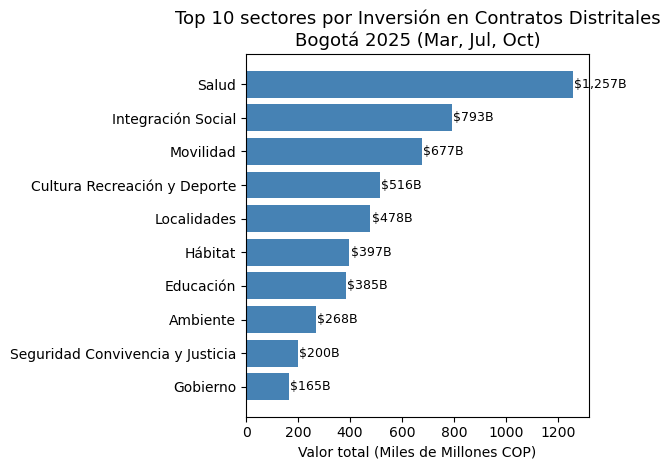

Grafica guardada


In [8]:
#Celda 7 - Grafica inversion por sector
top10= contratos_sector.head(10).sort_values('Valor_total_miles_millones')

plt.Figure(figsize=(12,7))
bars = plt.barh(top10['Sector'], top10['Valor_total_miles_millones'], color='steelblue')
plt.title('Top 10 sectores por Inversión en Contratos Distritales\nBogotá 2025 (Mar, Jul, Oct)', fontsize=13)
plt.xlabel('Valor total (Miles de Millones COP)')

for bar, val in zip(bars, top10['Valor_total_miles_millones']):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}B', va ='center', fontsize=9)
    
plt.tight_layout()
plt.savefig(r'C:\Users\jason\OneDrive\Documentos\GitHub\Portafolio-data-science\proyecto-2-contratos-distritales-bogota\grafica_inversion_sector.png', dpi=150)
plt.show()
print("Grafica guardada")


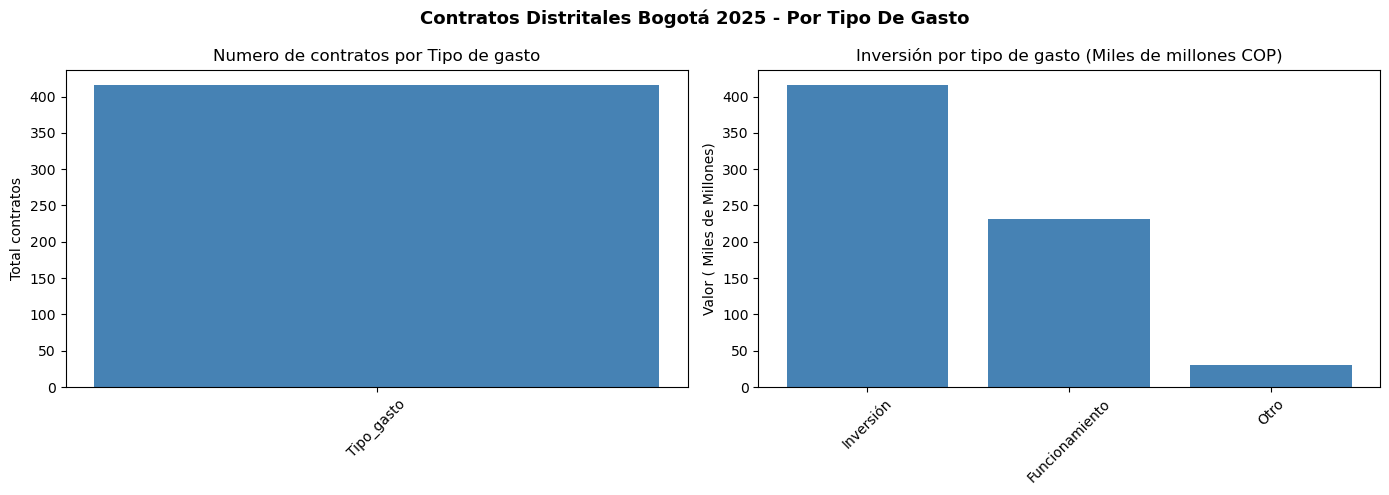

Grafica guardada


In [24]:
#Celda 8 - Contratos por tipo de gasto
tipo_gasto = df.groupby('Tipo de gasto').agg(
    Total_contratos = ('Tipo de gasto', 'count'),
    Valor_total = ('Valor', 'sum')
    ).reset_index()

tipo_gasto['Valor_miles_millones'] = tipo_gasto['Valor_total'] / 1e9
tipo_gasto = tipo_gasto.sort_values('Valor_miles_millones', ascending=False)

fig, axes = plt.subplots(1,2, figsize=(14, 5))

#Gráfica 1 - Por número de contratos
axes[0].bar(['Tipo_gasto'], tipo_gasto['Total_contratos'], color = 'steelblue')
axes[0].set_title('Numero de contratos por Tipo de gasto')
axes[0].set_ylabel('Total contratos')
axes[0].tick_params(axis='x', rotation = 45)

#Gráfica - 2 Por valor
axes[1].bar(tipo_gasto['Tipo de gasto'], tipo_gasto['Total_contratos'], color = 'steelblue')
axes[1].set_title('Inversión por tipo de gasto (Miles de millones COP)')
axes[1].set_ylabel('Valor ( Miles de Millones)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Contratos Distritales Bogotá 2025 - Por Tipo De Gasto', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\jason\OneDrive\Documentos\GitHub\Portafolio-data-science\proyecto-2-contratos-distritales-bogota\grafica_tipo_gasto.png', dpi=150)
plt.show()
print("Grafica guardada")





In [25]:
#Clda 9 - Conclusiones
print("""
╔══════════════════════════════════════════════════════════════╗
   CONCLUSIONES - CONTRATOS DISTRITALES BOGOTÁ 2025
╚══════════════════════════════════════════════════════════════╝

📊 DATOS ANALIZADOS:
   • 677 contratos distritales (Marzo, Julio, Octubre 2025)
   • 17 sectores de la administración distrital
   • Inversión total analizada: ~$4.8 billones COP

🔍 HALLAZGOS PRINCIPALES:
   1. Salud lidera la inversión con $1.25 billones en 37 contratos
      → Contratos de alto valor promedio (~$34,000 millones c/u)

   2. Localidades tiene el mayor número de contratos (137)
      pero menor valor promedio → Muchos contratos pequeños

   3. Movilidad ocupa el 3er lugar en inversión ($677 mil millones)
      → Infraestructura vial y transporte es prioridad distrital

   4. El 90%+ del gasto es Inversión vs Funcionamiento
      → El distrito prioriza obra y proyectos sobre operación

⚠️  LIMITACIÓN:
   Solo se analizaron 3 meses del año. Un análisis completo
   requiere los 12 meses para identificar patrones estacionales.

🎯 RECOMENDACIÓN:
   Cruzar con datos de ejecución presupuestal para verificar
   si los contratos firmados realmente se ejecutaron.
""")


╔══════════════════════════════════════════════════════════════╗
   CONCLUSIONES - CONTRATOS DISTRITALES BOGOTÁ 2025
╚══════════════════════════════════════════════════════════════╝

📊 DATOS ANALIZADOS:
   • 677 contratos distritales (Marzo, Julio, Octubre 2025)
   • 17 sectores de la administración distrital
   • Inversión total analizada: ~$4.8 billones COP

🔍 HALLAZGOS PRINCIPALES:
   1. Salud lidera la inversión con $1.25 billones en 37 contratos
      → Contratos de alto valor promedio (~$34,000 millones c/u)

   2. Localidades tiene el mayor número de contratos (137)
      pero menor valor promedio → Muchos contratos pequeños

   3. Movilidad ocupa el 3er lugar en inversión ($677 mil millones)
      → Infraestructura vial y transporte es prioridad distrital

   4. El 90%+ del gasto es Inversión vs Funcionamiento
      → El distrito prioriza obra y proyectos sobre operación

⚠️  LIMITACIÓN:
   Solo se analizaron 3 meses del año. Un análisis completo
   requiere los 12 meses para 